# 05 — Tuning vs Baseline

Notebook 04 ran 24 trials: two configurations × three seeds × four
architectures. It produced a table of numbers. This notebook turns those numbers
into a conclusion, or establishes that there isn't one.

It trains nothing. It reads what 04 wrote, compares it with the notebook 02
baseline, and states plainly whether the tuning helped.

## The comparison being made

Notebook 02 gave one accuracy per architecture, from one seed. That is a point
estimate with no error bar, on a 56-image test set where one image is worth
1.8%.

Notebook 04 ran the *same* configuration three times (`A_baseline`) and a
regularised configuration three times (`B_reg`). So now the baseline has a
spread, and the question is answerable:

> Is `B_reg` better than `A_baseline` by more than `A_baseline` varies from seed
> to seed?

If the difference is smaller than the seed spread, the tuning did nothing that
seed luck could not have produced. That is a real and common result, and this
notebook is written to report it as such rather than to bury it.

In [1]:
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)


def banner(msg):
    print("\n" + "=" * 74)
    print("  " + msg)
    print("=" * 74)


def find_project_root(start=None):
    here = Path(start or Path.cwd()).resolve()
    for cand in [here] + list(here.parents):
        if (cand / "notebooks").is_dir() and (cand / "results").is_dir():
            return cand
    return here


PROJECT_ROOT = find_project_root()
RESULTS = PROJECT_ROOT / "results"
OUT = RESULTS / "tuning_vs_baseline"
OUT.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT)

PROJECT_ROOT : /kaggle/working/BSM-Project


---
## 1. Inputs and completeness

Nothing is written before the inputs are checked. A tuning study read from a
partial `trials.csv` would silently compare different numbers of seeds per
configuration, which is exactly the kind of error that produces a confident
wrong conclusion.

In [2]:
banner("Load inputs")

TRIALS = RESULTS / "tuning" / "trials.csv"
SUMMARY = RESULTS / "tuning" / "per_config_summary.csv"
VERDICT = RESULTS / "tuning" / "tuning_verdict.json"
BASELINE = RESULTS / "metrics" / "final_results.csv"
PAPER = RESULTS / "metrics" / "paper_reference_values.csv"

missing = [p for p in [TRIALS, SUMMARY, VERDICT, BASELINE] if not p.exists()]
if missing:
    raise SystemExit(
        "Missing input(s):\n  " + "\n  ".join(str(m) for m in missing)
        + "\n\nRun 04_Tuning.ipynb first (and 02 for the baseline row)."
    )

trials = pd.read_csv(TRIALS)
summary = pd.read_csv(SUMMARY)
verdict = json.loads(VERDICT.read_text())
baseline = pd.read_csv(BASELINE)

print(f"  trials   : {len(trials)}")
print(f"  models   : {sorted(trials['model'].unique())}")
print(f"  configs  : {sorted(trials['config'].unique())}")
print(f"  seeds    : {sorted(trials['seed'].unique())}")
print(f"  baseline : {len(baseline)} rows from notebook 02")
print()

EXPECTED_MODELS = 4
EXPECTED_CONFIGS = 2
EXPECTED_SEEDS = 3
EXPECTED = EXPECTED_MODELS * EXPECTED_CONFIGS * EXPECTED_SEEDS

if len(trials) != EXPECTED:
    raise SystemExit(
        f"trials.csv has {len(trials)} rows, expected {EXPECTED} "
        f"({EXPECTED_MODELS} models x {EXPECTED_CONFIGS} configs x {EXPECTED_SEEDS} seeds). "
        "Re-run 04_Tuning.ipynb - it resumes and will fill the gaps."
    )

for model, g in trials.groupby("model"):
    for cfg, gg in g.groupby("config"):
        if len(gg) != EXPECTED_SEEDS:
            print(f"  WARNING {model}/{cfg}: {len(gg)} seeds, expected {EXPECTED_SEEDS}")

print(f"  completeness PASSED ({EXPECTED} trials)")


  Load inputs
  trials   : 24
  models   : ['D_ResNet', 'ResNet18', 'ResNet34', 'VGG16']
  configs  : ['A_baseline', 'B_reg']
  seeds    : [np.int64(42), np.int64(43), np.int64(44)]
  baseline : 4 rows from notebook 02

  completeness PASSED (24 trials)


---
## 2. What 04 measured, and what it did not

Stated up front because it bounds every conclusion below:

- 04 selected each trial's checkpoint on **validation accuracy**, then read test
  once. Configuration choice was made on validation.
- 04 recorded **accuracy only** per trial. It saved no per-class reports, no
  confusion matrices, and no checkpoints.

The second point has a real consequence: **per-class behaviour of the tuned
models is not recoverable.** Notebook 03 can show a class breakdown for the
baseline because 02 saved reports; 05 cannot show the same for `B_reg` without
re-running training, which would cost another 2-3 hours to answer a question the
accuracy table already answers. So this notebook compares at the aggregate level
and says so rather than implying a depth of analysis that the data does not
support.

In [3]:
banner("Per-class comparison: available or not")

rows = []
for p in sorted(RESULTS.glob("metrics/*_classification_report.csv")):
    model = p.name.replace("_classification_report.csv", "")
    try:
        r = pd.read_csv(p)
    except Exception:
        rows.append({"model": model, "baseline_per_class": "unreadable"})
        continue
    rows.append({"model": model,
                 "baseline_per_class": "yes",
                 "rows": len(r)})

per_class = pd.DataFrame(rows)
print(per_class.to_string(index=False))
print()
print("  Tuned models (04_Tuning)          : NO per-class data, NO checkpoints")
print("  Baseline models (02_Model_Experiments): per-class reports available")
print()
print("  => Any tuned-vs-baseline comparison in this notebook is aggregate")
print("     accuracy only. Per-class claims about tuned models are not supported.")


  Per-class comparison: available or not
   model baseline_per_class  rows
D_ResNet                yes     9
ResNet18                yes     9
ResNet34                yes     9
   VGG16                yes     9

  Tuned models (04_Tuning)          : NO per-class data, NO checkpoints
  Baseline models (02_Model_Experiments): per-class reports available

  => Any tuned-vs-baseline comparison in this notebook is aggregate
     accuracy only. Per-class claims about tuned models are not supported.


---
## 3. Baseline versus tuned

Three columns per architecture: what notebook 02 reported (one seed, 60 epochs),
what the baseline configuration did across three seeds, and what the regularised
configuration did across three seeds.

In [4]:
banner("Baseline vs tuned, per architecture")

base_cfg = "A_baseline"
tune_cfg = "B_reg"

if base_cfg not in set(summary["config"]) or tune_cfg not in set(summary["config"]):
    raise SystemExit(f"expected configs {base_cfg} and {tune_cfg}, "
                     f"found {sorted(summary['config'].unique())}")

nb02 = baseline.set_index("model")["test_accuracy"].to_dict()

rows = []
for model in summary["model"].drop_duplicates():
    sub = summary[summary["model"] == model]
    a = sub[sub["config"] == base_cfg]
    b = sub[sub["config"] == tune_cfg]
    if a.empty or b.empty:
        continue
    a, b = a.iloc[0], b.iloc[0]
    rows.append({
        "model": model,
        "nb02_seed42_60ep": nb02.get(model, np.nan),
        "A_baseline_mean": a["val_mean"],
        "A_baseline_sd": a["val_std"],
        "A_baseline_test_mean": a["test_mean"],
        "A_baseline_test_sd": a["test_std"],
        "B_reg_val_mean": b["val_mean"],
        "B_reg_val_sd": b["val_std"],
        "B_reg_test_mean": b["test_mean"],
        "B_reg_test_sd": b["test_std"],
        "val_delta_B_minus_A": b["val_mean"] - a["val_mean"],
        "test_delta_B_minus_A": b["test_mean"] - a["test_mean"],
        "baseline_test_range": a["test_max"] - a["test_min"],
    })

cmp_df = pd.DataFrame(rows)
cmp_df.to_csv(OUT / "baseline_vs_tuned.csv", index=False)

show = ["model", "nb02_seed42_60ep", "A_baseline_test_mean", "A_baseline_test_sd",
        "B_reg_test_mean", "B_reg_test_sd", "test_delta_B_minus_A",
        "baseline_test_range"]
print("TEST accuracy (mean +/- sd over 3 seeds), and the 02 point estimate:")
print()
print(cmp_df[show].round(4).to_string(index=False))


  Baseline vs tuned, per architecture
TEST accuracy (mean +/- sd over 3 seeds), and the 02 point estimate:

   model  nb02_seed42_60ep  A_baseline_test_mean  A_baseline_test_sd  B_reg_test_mean  B_reg_test_sd  test_delta_B_minus_A  baseline_test_range
D_ResNet            0.6964                0.7143              0.0309           0.7857         0.0309                0.0714               0.0536
ResNet18            0.8036                0.7679              0.0179           0.8036         0.0357                0.0357               0.0357
ResNet34            0.7321                0.7321              0.0472           0.7619         0.0273                0.0298               0.0893
   VGG16            0.7679                0.7143              0.0179           0.7321         0.0179                0.0179               0.0357


---
## 4. The decisive test

A configuration only counts as better if its mean **validation** accuracy beats
the baseline's mean by more than the baseline's own seed-to-seed standard
deviation. Otherwise the gap is inside the noise.

Note the selection metric is validation, not test. The test columns are printed
for transparency and play no part in the verdict.

In [5]:
banner("Decisive test (selection on VALIDATION)")

lines, wins, ties = [], [], []

for _, r in cmp_df.iterrows():
    model = r["model"]
    delta = r["val_delta_B_minus_A"]
    sd = r["A_baseline_sd"]
    if not np.isfinite(sd):
        verdict_txt = "baseline sd unavailable (single seed) - cannot judge"
    elif delta > sd:
        verdict_txt = "B_reg EXCEEDS baseline seed spread -> real"
        wins.append(model)
    elif delta < -sd:
        verdict_txt = "A_baseline exceeds B_reg by more than its spread -> B_reg worse"
        ties.append(model)
    else:
        verdict_txt = "inside baseline seed spread -> INCONCLUSIVE"
        ties.append(model)
    lines.append(f"  {model:<10} val A={r['A_baseline_mean']:.4f} (sd {sd:.4f})  "
                 f"B={r['B_reg_val_mean']:.4f}  delta={delta:+.4f}  -> {verdict_txt}")

print("\n".join(lines))
print()
print(f"  B_reg genuinely better : {wins if wins else 'none'}")
print(f"  inconclusive / worse   : {ties if ties else 'none'}")
print()
print("  Reading: one test image is 1.8% of accuracy (1/56). A gap smaller than")
print("  the baseline's own seed spread is indistinguishable from which seed ran.")


  Decisive test (selection on VALIDATION)
  D_ResNet   val A=0.8364 (sd 0.0182)  B=0.8424  delta=+0.0061  -> inside baseline seed spread -> INCONCLUSIVE
  ResNet18   val A=0.8788 (sd 0.0278)  B=0.8727  delta=-0.0061  -> inside baseline seed spread -> INCONCLUSIVE
  ResNet34   val A=0.8182 (sd 0.0315)  B=0.8485  delta=+0.0303  -> inside baseline seed spread -> INCONCLUSIVE
  VGG16      val A=0.8485 (sd 0.0105)  B=0.8485  delta=+0.0000  -> inside baseline seed spread -> INCONCLUSIVE

  B_reg genuinely better : none
  inconclusive / worse   : ['D_ResNet', 'ResNet18', 'ResNet34', 'VGG16']

  Reading: one test image is 1.8% of accuracy (1/56). A gap smaller than
  the baseline's own seed spread is indistinguishable from which seed ran.


---
## 5. Seed spread as the headline result

Sometimes the most informative thing a tuning study produces is not the winner
but the error bar on the thing you thought you knew. This is that error bar.

In [6]:
banner("Seed-to-seed spread of the notebook 02 configuration")

spread = cmp_df[["model", "nb02_seed42_60ep", "A_baseline_test_mean",
                 "A_baseline_test_sd", "baseline_test_range"]].copy()

print("How far the SAME configuration moves across three seeds:")
print()
print(spread.round(4).to_string(index=False))
print()
for _, r in cmp_df.iterrows():
    sd = r["A_baseline_test_sd"]
    if np.isfinite(sd):
        print(f"  {r['model']:<10} sd {sd:.4f} = {sd * 56:.1f} test images of movement")
print()
print("  Notebook 02 reported one seed per model. Any architecture gap smaller")
print("  than these spreads was not resolvable from that run.")


  Seed-to-seed spread of the notebook 02 configuration
How far the SAME configuration moves across three seeds:

   model  nb02_seed42_60ep  A_baseline_test_mean  A_baseline_test_sd  baseline_test_range
D_ResNet            0.6964                0.7143              0.0309               0.0536
ResNet18            0.8036                0.7679              0.0179               0.0357
ResNet34            0.7321                0.7321              0.0472               0.0893
   VGG16            0.7679                0.7143              0.0179               0.0357

  D_ResNet   sd 0.0309 = 1.7 test images of movement
  ResNet18   sd 0.0179 = 1.0 test images of movement
  ResNet34   sd 0.0472 = 2.6 test images of movement
  VGG16      sd 0.0179 = 1.0 test images of movement

  Notebook 02 reported one seed per model. Any architecture gap smaller
  than these spreads was not resolvable from that run.


In [7]:
banner("Trial-level detail")

cols = ["model", "config", "seed", "best_epoch", "best_val_accuracy", "test_accuracy",
        "mean_epoch_seconds"]
print(trials[cols].sort_values(["model", "config", "seed"]).round(4).to_string(index=False))
print()
print("  Best epochs are mostly early; a 20-epoch budget was not the constraint.")


  Trial-level detail
   model     config  seed  best_epoch  best_val_accuracy  test_accuracy  mean_epoch_seconds
D_ResNet A_baseline    42           3             0.8364         0.6964             13.5057
D_ResNet A_baseline    43          15             0.8545         0.7500             13.3220
D_ResNet A_baseline    44          10             0.8182         0.6964             13.3086
D_ResNet      B_reg    42           4             0.8545         0.8036             13.4248
D_ResNet      B_reg    43           2             0.8364         0.7500             13.4510
D_ResNet      B_reg    44           2             0.8364         0.8036             13.4447
ResNet18 A_baseline    42          20             0.9091         0.7500              5.5822
ResNet18 A_baseline    43           1             0.8545         0.7679              5.0523
ResNet18 A_baseline    44           2             0.8727         0.7857              5.0543
ResNet18      B_reg    42          17             0.8909  

---
## 6. Figure


  Test accuracy by configuration, seeds shown individually
  wrote /kaggle/working/BSM-Project/results/tuning_vs_baseline/tuning_vs_baseline.png


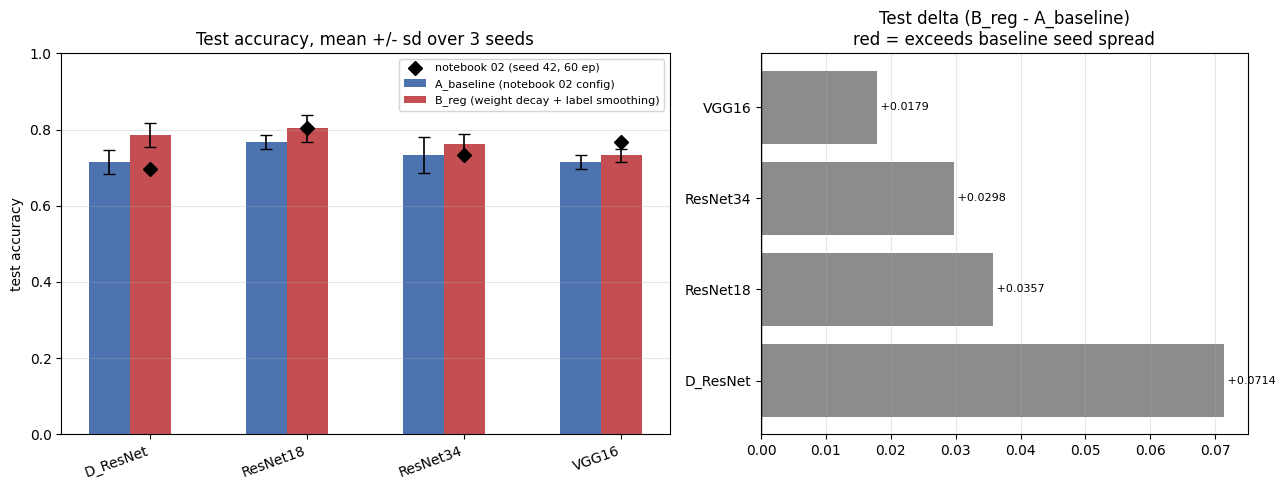

In [8]:
banner("Test accuracy by configuration, seeds shown individually")

fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                         gridspec_kw={"width_ratios": [1.25, 1]})

ax = axes[0]
models = list(cmp_df["model"])
x = np.arange(len(models))
w = 0.26

series = [
    (-w, "A_baseline", "#4C72B0", f"{base_cfg} (notebook 02 config)"),
    (0.0, "B_reg", "#C44E52", f"{tune_cfg} (weight decay + label smoothing)"),
]
for off, prefix, color, lbl in series:
    sub = cmp_df.set_index("model").loc[models]
    ax.bar(x + off, sub[f"{prefix}_test_mean"], w,
           yerr=sub[f"{prefix}_test_sd"], capsize=4, color=color, label=lbl,
           error_kw={"elinewidth": 1.2})

pts = [cmp_df[cmp_df["model"] == m]["nb02_seed42_60ep"].iloc[0] for m in models]
ax.plot(x, pts, "kD", markersize=7, label="notebook 02 (seed 42, 60 ep)")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha="right")
ax.set_ylabel("test accuracy")
ax.set_ylim(0, 1.0)
ax.set_title("Test accuracy, mean +/- sd over 3 seeds")
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=8)

ax = axes[1]
labels = list(cmp_df["model"])
deltas = list(cmp_df["test_delta_B_minus_A"])
colors = []
for _, r in cmp_df.iterrows():
    sd = r["A_baseline_sd"]
    decisive = np.isfinite(sd) and abs(r["val_delta_B_minus_A"]) > sd
    colors.append("#C44E52" if decisive else "#8C8C8C")
ax.barh(labels, deltas, color=colors)
ax.axvline(0, color="k", lw=1)
ax.set_title("Test delta (B_reg - A_baseline)\nred = exceeds baseline seed spread")
ax.grid(axis="x", alpha=0.3)
for i, d in enumerate(deltas):
    ax.text(d, i, f" {d:+.4f}", va="center", fontsize=8)

plt.tight_layout()
out_png = OUT / "tuning_vs_baseline.png"
plt.savefig(out_png, dpi=120)
print(f"  wrote {out_png}")

---
## 7. Written conclusion

Generated from the actual numbers rather than hand-written, so it cannot drift
out of sync with the tables above.

In [9]:
banner("Conclusion")

def fmt(x, nd=4):
    return "n/a" if x is None or not np.isfinite(x) else f"{x:.{nd}f}"


lines = ["# 05 — Tuning vs Baseline (generated)", ""]
lines.append("## Outcome per architecture")
lines.append("")
lines.append("Selection was on **validation** accuracy across three seeds; the test "
             "columns are reported for transparency and were not used to choose.")
lines.append("")
lines.append("| Model | A_baseline test (mean±sd) | B_reg test (mean±sd) | Δ test | Verdict |")
lines.append("|---|---|---|---|---|")
for _, r in cmp_df.iterrows():
    sd = r["A_baseline_sd"]
    if np.isfinite(sd) and r["val_delta_B_minus_A"] > sd:
        v = "B_reg better beyond seed spread"
    elif np.isfinite(sd) and r["val_delta_B_minus_A"] < -sd:
        v = "A_baseline better; B_reg did not help"
    elif np.isfinite(sd):
        v = "inconclusive (inside seed spread)"
    else:
        v = "not judgeable (single seed)"
    lines.append(
        f"| {r['model']} | {fmt(r['A_baseline_test_mean'])} ± {fmt(r['A_baseline_test_sd'])} "
        f"| {fmt(r['B_reg_test_mean'])} ± {fmt(r['B_reg_test_sd'])} "
        f"| {r['test_delta_B_minus_A']:+.4f} | {v} |")

lines += ["", "## Seed spread of the notebook 02 configuration", ""]
lines.append("| Model | seed 42 (60 ep) | mean of 3 seeds | sd | movement in test images |")
lines.append("|---|---|---|---|---|")
for _, r in cmp_df.iterrows():
    sd = r["A_baseline_test_sd"]
    images = "n/a" if not np.isfinite(sd) else f"{sd * 56:.1f}"
    lines.append(
        f"| {r['model']} | {fmt(r['nb02_seed42_60ep'])} | {fmt(r['A_baseline_test_mean'])} "
        f"| {fmt(sd)} | {images} |")

lines += [
    "",
    "## Limitations",
    "",
    "- **Aggregate only.** Notebook 04 recorded test accuracy per trial and no "
    "per-class reports, confusion matrices or checkpoints, so the tuned models "
    "cannot be broken down by class. Only the baseline has that detail.",
    "- **56 test images.** One image is 1.8% of accuracy. Wilson intervals for any "
    "single configuration are wide, and three seeds narrow the baseline's spread "
    "but do not shrink the test set.",
    "- **One split, three seeds.** These seeds measure training variability on a "
    "single fixed split. They do not measure split variability, which for 256 "
    "unique training images is likely the larger of the two.",
    "- **20-epoch trials** against a 60-epoch baseline. Comparable in the sense "
    "that best epochs were early, but the baseline numbers here are not a "
    "re-trained 20-epoch control.",
    "- **Near-duplicate and background confounding** documented in the README "
    "applies unchanged to every tuned model.",
    "- **No architecture ranking is claimed** from either notebook.",
]

md_out = OUT / "tuning_vs_baseline.md"
md_out.write_text("\n".join(lines) + "\n", encoding="utf-8")
print("\n".join(lines))
print(f"\n  wrote {md_out}")


  Conclusion
# 05 — Tuning vs Baseline (generated)

## Outcome per architecture

Selection was on **validation** accuracy across three seeds; the test columns are reported for transparency and were not used to choose.

| Model | A_baseline test (mean±sd) | B_reg test (mean±sd) | Δ test | Verdict |
|---|---|---|---|---|
| D_ResNet | 0.7143 ± 0.0309 | 0.7857 ± 0.0309 | +0.0714 | inconclusive (inside seed spread) |
| ResNet18 | 0.7679 ± 0.0179 | 0.8036 ± 0.0357 | +0.0357 | inconclusive (inside seed spread) |
| ResNet34 | 0.7321 ± 0.0472 | 0.7619 ± 0.0273 | +0.0298 | inconclusive (inside seed spread) |
| VGG16 | 0.7143 ± 0.0179 | 0.7321 ± 0.0179 | +0.0179 | inconclusive (inside seed spread) |

## Seed spread of the notebook 02 configuration

| Model | seed 42 (60 ep) | mean of 3 seeds | sd | movement in test images |
|---|---|---|---|---|
| D_ResNet | 0.6964 | 0.7143 | 0.0309 | 1.7 |
| ResNet18 | 0.8036 | 0.7679 | 0.0179 | 1.0 |
| ResNet34 | 0.7321 | 0.7321 | 0.0472 | 2.6 |
| VGG16 | 0.76

---
## 8. Package and hand off

Notebook 03 already bundles results for 01-03. This notebook adds the tuning
outputs and is the last notebook in the sequence, so it re-runs the bundling with
everything included.

Google Drive is not available on Kaggle. Rather than fail, the packager detects
Drive and falls back to writing a zip into the working directory, which Kaggle
ships as notebook output.

In [10]:
banner("Package results and executed notebooks")

import shutil
import zipfile

STAGE = RESULTS / "_stage_tuning"
if STAGE.exists():
    shutil.rmtree(STAGE)
(STAGE / "results").mkdir(parents=True, exist_ok=True)
(STAGE / "notebooks").mkdir(parents=True, exist_ok=True)

copied = 0
for p in sorted(RESULTS.rglob("*")):
    if not p.is_file():
        continue
    rel = p.relative_to(RESULTS)
    if rel.parts[0].startswith("_stage") or p.suffix.lower() in {".pth", ".pt", ".ckpt"}:
        continue
    dst = STAGE / "results" / rel
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(p, dst)
    copied += 1

nb_copied = []
for nb in sorted((PROJECT_ROOT / "notebooks").glob("*.ipynb")):
    shutil.copy2(nb, STAGE / "notebooks" / nb.name)
    nb_copied.append(nb.name)

print(f"  staged {copied} result file(s)")
print(f"  staged {len(nb_copied)} notebook(s): {nb_copied}")

DRIVE_BASE = Path("/content/drive/MyDrive/BSM_Mineral_Classification")
if DRIVE_BASE.parent.is_dir():
    target = DRIVE_BASE
else:
    target = Path("/kaggle/working")
    print("  no Google Drive here (expected on Kaggle) - writing zip locally")

target.mkdir(parents=True, exist_ok=True)
stamp = time.strftime("%Y%m%d-%H%M%S")
zip_path = target / f"BSM_results_tuning_{stamp}.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in sorted(STAGE.rglob("*")):
        if p.is_file():
            z.write(p, p.relative_to(STAGE))

shutil.rmtree(STAGE)

size_mb = zip_path.stat().st_size / 1e6
print(f"\n  wrote {zip_path}  ({size_mb:.2f} MB)")
if size_mb > 40:
    print("  WARNING: bundle is larger than expected - check for stray files")
else:
    print("  bundle size sane; no checkpoints included")


  Package results and executed notebooks
  staged 89 result file(s)
  staged 5 notebook(s): ['01_Data_Preprocessing_and_EDA.ipynb', '02_Model_Experiments.ipynb', '03_Final_Comparison.ipynb', '04_Tuning.ipynb', '05_Tuning_vs_Baseline.ipynb']
  no Google Drive here (expected on Kaggle) - writing zip locally

  wrote /kaggle/working/BSM_results_tuning_20261001-025432.zip  (5.80 MB)
  bundle size sane; no checkpoints included


In [11]:
banner("Contents of this notebook's outputs")

for p in sorted(OUT.glob("*")):
    print(f"  {p.name:<32} {p.stat().st_size / 1024:8.1f} KB")

print()
print("  Deliverables:")
print("    baseline_vs_tuned.csv   per-model side-by-side with spreads")
print("    baseline_vs_tuned.md    generated conclusion and limitations")
print("    tuning_vs_baseline.png  bar chart with seed-spread markers")
print("    ../tuning/              the 24 trials themselves")


  Contents of this notebook's outputs
  baseline_vs_tuned.csv                 1.1 KB
  tuning_vs_baseline.md                 2.0 KB
  tuning_vs_baseline.png               66.4 KB

  Deliverables:
    baseline_vs_tuned.csv   per-model side-by-side with spreads
    baseline_vs_tuned.md    generated conclusion and limitations
    tuning_vs_baseline.png  bar chart with seed-spread markers
    ../tuning/              the 24 trials themselves
